In [899]:
import numpy as np #
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [900]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 이상치 확인

In [901]:
df=pd.read_csv('/content/drive/MyDrive/2차 프로젝트/data/dataset.csv')

In [902]:
# transaction_data.csv 완료

In [903]:
print(df.dtypes)
print(df.info())

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       -------

In [904]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [905]:
df.describe(include='number')
# 수치형  Tenure WarehouseToHome	HourSpendOnApp NumberOfDeviceRegistered NumberOfAddress OrderAmountHikeFromlastYear OrderCount DaySinceLastOrder CashbackAmount
# 범주형	CustomerID Churn CityTier SatisfactionScore Complain CouponUsed PreferredLoginDevice	PreferredPaymentMode	Gender	PreferedOrderCat	MaritalStatus

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [906]:
df.describe(include='object')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [907]:
#SMOTE 필요

## 이상치 처리

이상치란: 관측된 데이터의 일반적인 범위를 크게 벗어난 데이터

### Tenure


In [908]:
df['Tenure'].skew(),df['Tenure'].kurt()

(np.float64(0.7365133838993447), np.float64(-0.007369469517085392))

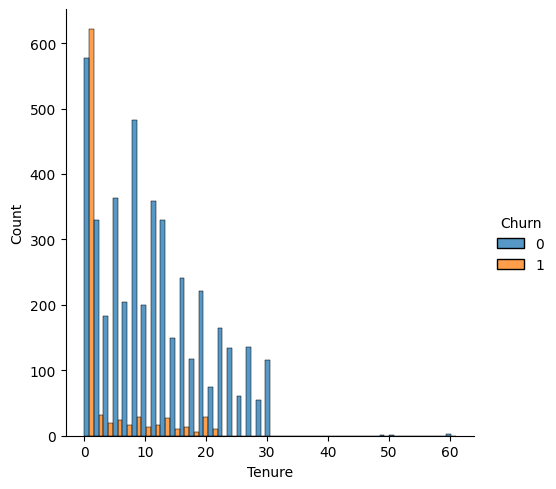

In [909]:
sns.displot(df, x="Tenure", hue="Churn", multiple="dodge")

<Axes: ylabel='Tenure'>

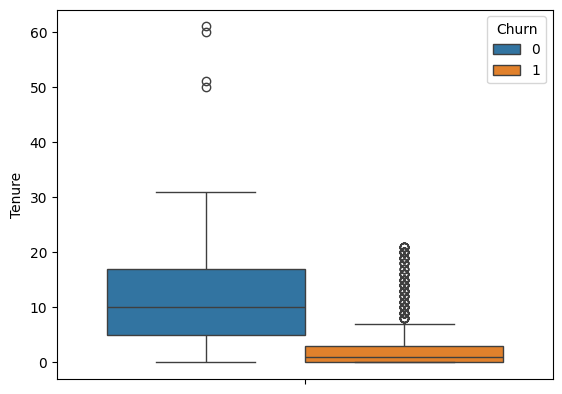

In [910]:
sns.boxplot(y=df['Tenure'],hue="Churn", data=df)

In [911]:
 df['Tenure1'] = np.log1p(df["Tenure"])  #log1p 함수로 이상치 해소

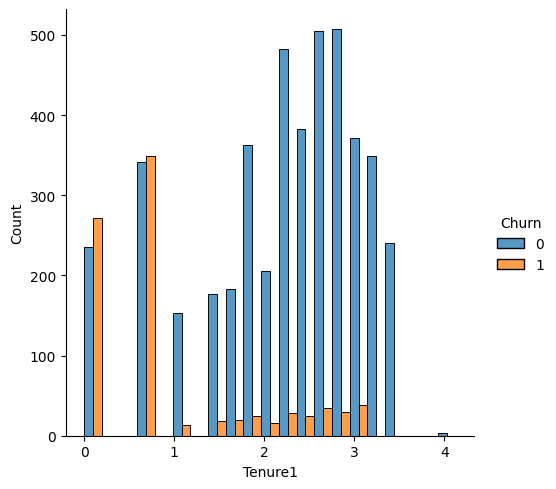

In [912]:
sns.displot(df, x="Tenure1", hue="Churn", multiple="dodge")

<Axes: ylabel='Tenure1'>

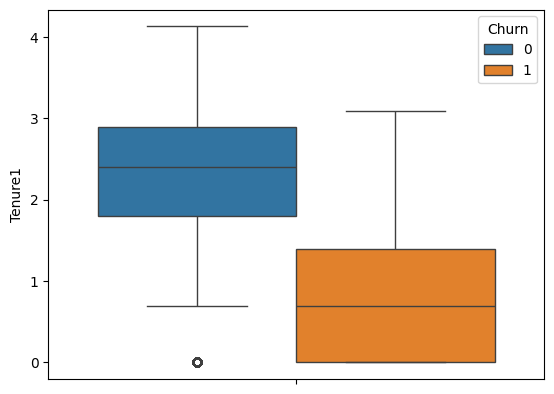

In [913]:
sns.boxplot(y=df['Tenure1'],hue="Churn", data=df)

In [914]:
df['Tenure1'].skew()

np.float64(-0.5880197463521782)

In [915]:
# Tenure 이상치 해소

### WarehouseToHome

In [916]:
df['WarehouseToHome'].skew(),df['WarehouseToHome'].kurt()

(np.float64(1.619153668208649), np.float64(9.986930421469834))

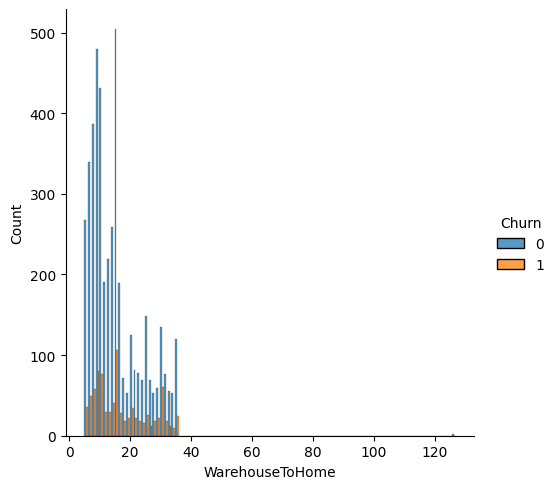

In [917]:
sns.displot(df, x="WarehouseToHome", hue="Churn", multiple="dodge")


<Axes: ylabel='WarehouseToHome'>

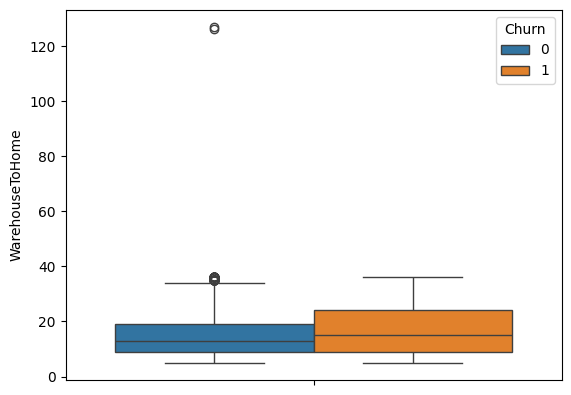

In [918]:
sns.boxplot(y=df['WarehouseToHome'],hue="Churn", data=df)

In [919]:
 df['WarehouseToHome1'] = np.log1p(df["WarehouseToHome"])  #log1p 함수로 이상치 해소


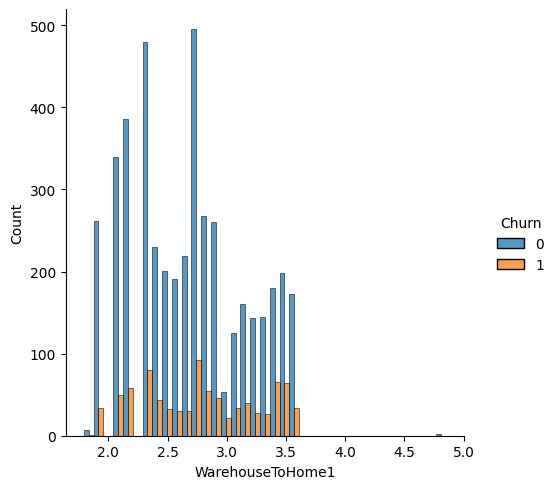

In [920]:
sns.displot(df, x="WarehouseToHome1", hue="Churn", multiple="dodge")

<Axes: ylabel='WarehouseToHome1'>

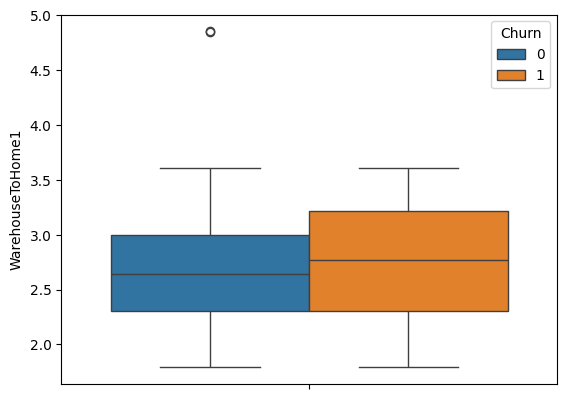

In [921]:
sns.boxplot(y=df['WarehouseToHome1'],hue="Churn", data=df)

In [922]:
df['WarehouseToHome1'].skew(),df['WarehouseToHome1'].kurt()

(np.float64(0.2907681080870872), np.float64(-0.8829997424312968))

In [923]:
# WarehouseToHome는 이상치 해소

### DaySinceLastOrder

In [924]:
df['DaySinceLastOrder'].skew(),df['DaySinceLastOrder'].kurt()

(np.float64(1.1909995034566865), np.float64(4.023964341230753))

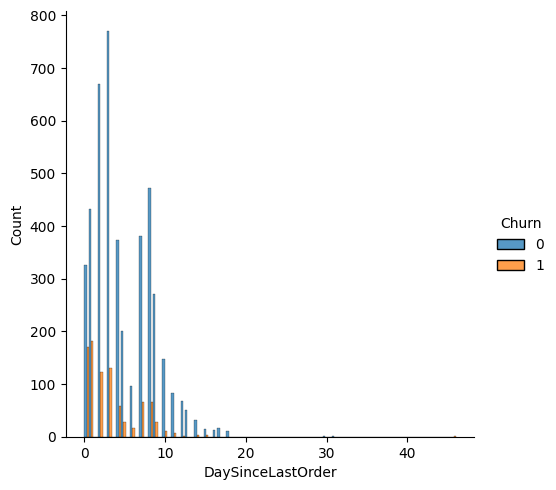

In [925]:
sns.displot(df, x="DaySinceLastOrder", hue="Churn", multiple="dodge")

<Axes: ylabel='DaySinceLastOrder'>

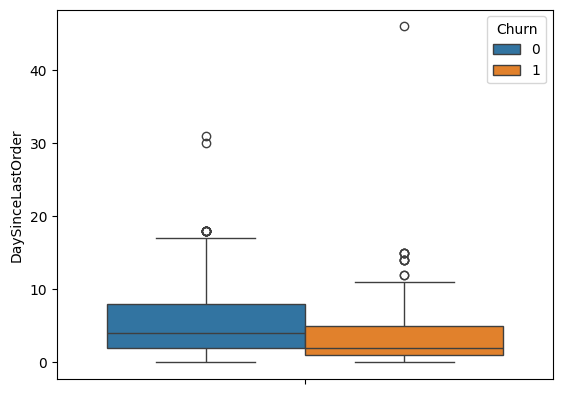

In [926]:
sns.boxplot(y=df['DaySinceLastOrder'],hue="Churn", data=df)

In [927]:
 df['DaySinceLastOrder1'] = np.log1p(df["DaySinceLastOrder"])

In [928]:
df['DaySinceLastOrder1'].skew(),df['DaySinceLastOrder1'].kurt()

(np.float64(-0.3892436356794331), np.float64(-0.5444541085865882))

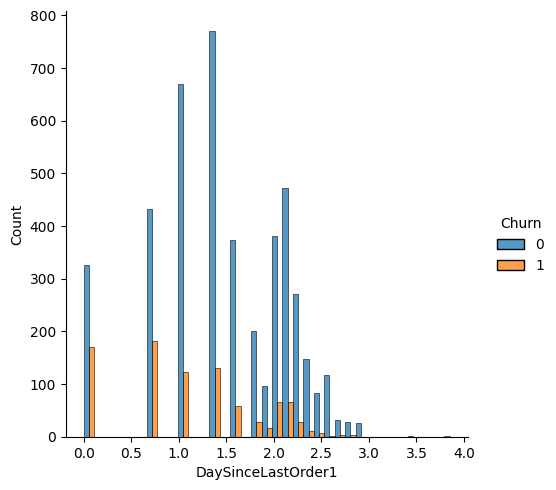

In [929]:
sns.displot(df, x="DaySinceLastOrder1", hue="Churn", multiple="dodge")

<Axes: ylabel='DaySinceLastOrder1'>

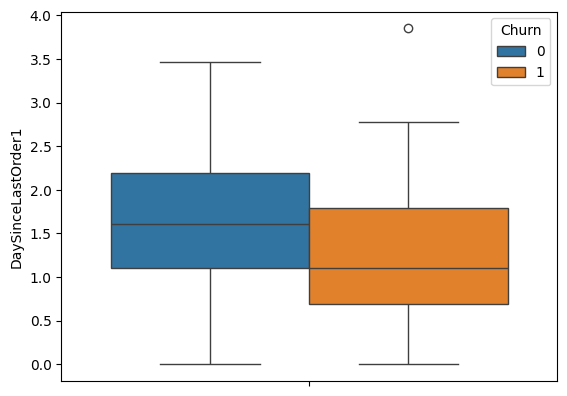

In [930]:
sns.boxplot(y=df['DaySinceLastOrder1'],hue="Churn", data=df)

### CashbackAmount

In [931]:
df['CashbackAmount'].skew(),df['CashbackAmount'].kurt()

(np.float64(1.1495949962274574), np.float64(0.9735461686576548))

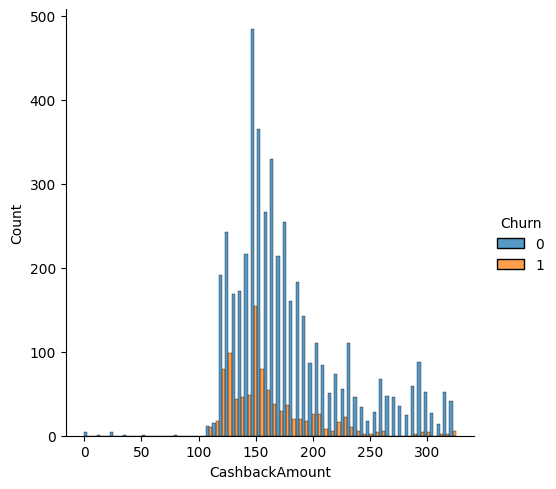

In [932]:
sns.displot(df, x="CashbackAmount", hue="Churn", multiple="dodge")

<Axes: ylabel='CashbackAmount'>

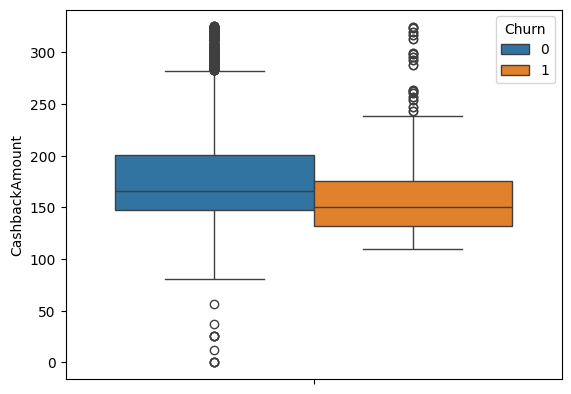

In [933]:
sns.boxplot(y=df['CashbackAmount'],hue="Churn", data=df)

In [934]:
df['CashbackAmount1'] = df['CashbackAmount'].clip(lower=100,upper=240)

In [935]:
df['CashbackAmount1'].skew(),df['CashbackAmount1'].kurt()

(np.float64(0.5613319475312226), np.float64(-0.8015237489573286))

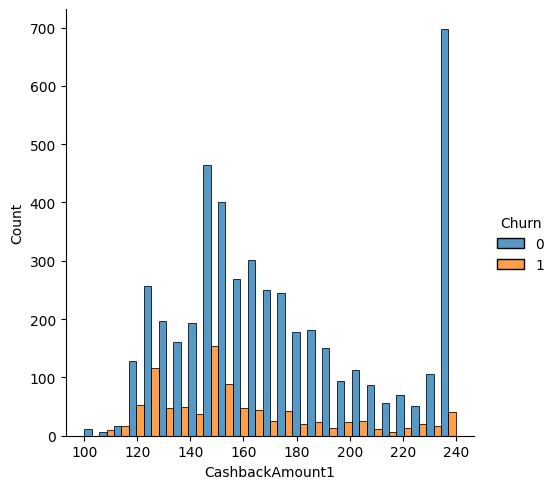

In [936]:
sns.displot(df, x="CashbackAmount1", hue="Churn", multiple="dodge")

<Axes: ylabel='CashbackAmount1'>

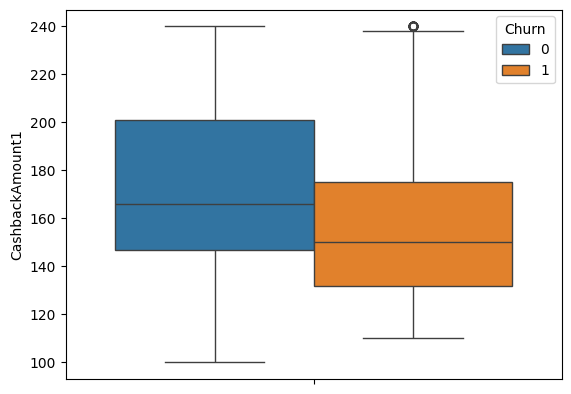

In [937]:
sns.boxplot(y=df['CashbackAmount1'],hue="Churn", data=df)

## 결론

In [938]:
def outlier_control(df,cols):


  for col in cols:
    if col == 'CashbackAmount':
      df[f'{col}_clip'] = df['CashbackAmount'].clip(lower=100,upper=240)

    else:
      df[f'{col}_log'] = np.log1p(df[col])


  df.drop(cols, axis=1, inplace=True) # 원본 피처가 필요하면 이부분 주석처리하고 사용하세요




cols=['Tenure','WarehouseToHome','DaySinceLastOrder','CashbackAmount']

outlier_control(df,cols)

In [939]:
df.head()

,CustomerID,Churn,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,CouponUsed,OrderCount,Tenure1,WarehouseToHome1,DaySinceLastOrder1,CashbackAmount1,Tenure_log,WarehouseToHome_log,DaySinceLastOrder_log,CashbackAmount_clip
0,50001,1,Mobile Phone,3,Debit Card,Female,3.0,3,Laptop & Accessory,2,...,1.0,1.0,1.609438,1.945910,1.791759,160,1.609438,1.945910,1.791759,160
1,50002,1,Phone,1,UPI,Male,3.0,4,Mobile,3,...,0.0,1.0,NaN,2.197225,0.000000,121,NaN,2.197225,0.000000,121
2,50003,1,Phone,1,Debit Card,Male,2.0,4,Mobile,3,...,0.0,1.0,NaN,3.433987,1.386294,120,NaN,3.433987,1.386294,120
3,50004,1,Phone,3,Debit Card,Male,2.0,4,Laptop & Accessory,5,...,0.0,1.0,0.000000,2.772589,1.386294,134,0.000000,2.772589,1.386294,134
4,50005,1,Phone,1,CC,Male,NaN,3,Mobile,5,...,1.0,1.0,0.000000,2.564949,1.386294,130,0.000000,2.564949,1.386294,130
